# Unidad 3 · MLCLSP: planificar los dos niveles a la vez

**Planta:** Conservas del Itata S.A.
**Datos:** `DatosClases/3_Planificacion/Planificiacion/` — la misma instancia de los cuadernos 02 a 04, más `itata_bom.csv` e `itata_insumos.csv`
**Solver:** Gurobi

---

## Qué se decide aquí

Hasta ahora el tarro de duraznos aparecía en el modelo como una sola cosa que
se produce. No lo es. Primero se **cocina el preparado a granel** (PREP-DUR)
en las marmitas y después se **envasa** en la línea. Son dos operaciones, con
dos preparaciones, dos inventarios y una relación de materiales entre ellas:
una caja de DUR-480 consume 11,8656 kg de granel, merma incluida.

El CLSP de los cuadernos anteriores no ignoraba las marmitas —están ahí, como
el recurso `PREP`—, pero las trataba como un recurso que consume el producto
terminado. Es una simplificación: **imputaba** las horas del granel al tarro.
Funciona mientras no haya que decidir *cuándo* cocinar, y deja de funcionar en
cuanto uno se pregunta si conviene cocinar en la semana 3 para envasar en la 5.

El **MLCLSP** (*multi-level capacitated lot-sizing problem*) planifica ambos
niveles a la vez. La única diferencia estructural con el CLSP es que la
demanda del granel **no es un dato**: es *dependiente*, y la genera el nivel
de arriba.

## La trampa del cuaderno

Al bajar de un nivel a dos hay que hacer una cosa que no es obvia y que
arruina la mitad de los modelos multinivel que se escriben por primera vez:
**dejar de imputar al producto terminado las horas que ahora consume el
componente.** Si se agrega el consumo del granel sin quitar el del tarro, la
carga del cuello de botella se cuenta dos veces, y el modelo no da un plan
caro: da `INFEASIBLE`. La sección 3 lo demuestra resolviéndolo.

## Cifras de referencia

| modelo | costo (CLP) | estado |
|---|---|---|
| MLCLSP, horas de marmita contadas **dos veces** | — | **INFEASIBLE** |
| MLCLSP correcto (granel y envasado en la misma semana) | **21 382 808** | OPTIMAL |
| MLCLSP con desfase de un período entre niveles | **37 479 417** | OPTIMAL |

El desfase **multiplica el costo por 1,75**. No es un recargo: es una
consecuencia de obligar a adelantar toda la cadena una semana.

In [1]:
import sys
import time
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

from comun import datos, tabla, figura, resumen, verificar, estilo

estilo()

dem = pd.read_csv(datos("3_Planificacion", "itata_demanda_plan.csv"))
par = pd.read_csv(datos("3_Planificacion", "itata_parametros_sku.csv"))
cap = pd.read_csv(datos("3_Planificacion", "itata_capacidad.csv"))
tas = pd.read_csv(datos("3_Planificacion", "itata_tasas.csv"))
ini = pd.read_csv(datos("3_Planificacion", "itata_inventario_inicial.csv"))
bom_df = pd.read_csv(datos("3_Planificacion", "itata_bom.csv"))
ins = pd.read_csv(datos("3_Planificacion", "itata_insumos.csv"))

SKUS = list(par.sku)
T = sorted(dem.t.unique().tolist())
REC = sorted(cap.recurso.unique().tolist())
p = par.set_index("sku")

demanda = {(r.sku, int(r.t)): float(r.demanda_cajas) for _, r in dem.iterrows()}
costo_setup = {i: float(p.loc[i, "costo_setup_clp"]) for i in SKUS}
costo_almacen = {i: float(p.loc[i, "costo_almacen_clp_caja_sem"]) for i in SKUS}
costo_backlog = {i: float(p.loc[i, "costo_backlog_clp_caja_sem"]) for i in SKUS}
stock_seg = {i: float(p.loc[i, "stock_seguridad_cajas"]) for i in SKUS}
inv_final_min = dict(stock_seg)

_ini = dict(zip(ini["item"], ini.inventario_inicial.astype(float)))
inv_ini = {i: _ini.get(i, 0.0) for i in SKUS}

linea = dict(zip(tas.sku, tas.linea))
consumo = {}
for _, r in tas.iterrows():
    consumo[(r.sku, "PREP")] = float(r.h_por_caja_PREP)
    consumo[(r.sku, "AUT")] = float(r.h_por_caja_AUT)
    consumo[(r.sku, r.linea)] = float(r.h_por_caja_linea)
tiempo_setup = {(r.sku, linea[r.sku]): float(r.tiempo_setup_h) for _, r in par.iterrows()}

capacidad = {(r.recurso, int(r.t)): float(r.horas_disponibles) for _, r in cap.iterrows()}
extra_max = {(r.recurso, int(r.t)): float(r.horas_extra_max) for _, r in cap.iterrows()}
costo_extra = {(r.recurso, int(r.t)): float(r.costo_hora_extra_clp) for _, r in cap.iterrows()}

print(f"{len(SKUS)} SKU · {len(T)} semanas · recursos {REC}")
print(bom_df.to_string(index=False))

6 SKU · 12 semanas · recursos ['AUT', 'L1', 'L2', 'PREP']
   padre       hijo  nivel  cantidad unidad  merma
 DUR-480   PREP-DUR      1   11.8656     kg  0.030
 DUR-480   HOJALATA      2   24.0000  tarro  0.000
 DUR-820   PREP-DUR      1   10.1352     kg  0.030
 DUR-820   HOJALATA      2   12.0000  tarro  0.000
 TOM-480   PREP-TOM      1   11.7274     kg  0.018
 TOM-480   HOJALATA      2   24.0000  tarro  0.000
TOM-3000   PREP-TOM      1   18.3240     kg  0.018
TOM-3000   HOJALATA      2    6.0000  tarro  0.000
 POR-480   PREP-POR      1   11.8080     kg  0.025
 POR-480   HOJALATA      2   24.0000  tarro  0.000
POR-3000   PREP-POR      1   18.4500     kg  0.025
POR-3000   HOJALATA      2    6.0000  tarro  0.000
PREP-DUR  FRUTA-DUR      2    1.2400     kg  0.000
PREP-TOM  PASTA-TOM      2    1.0800     kg  0.000
PREP-POR POROTO-SEC      2    0.4600     kg  0.000


## 1. La lista de materiales tiene dos niveles y medio

La tabla de arriba trae tres tipos de arco, y conviene separarlos antes de
escribir una sola restricción:

* **Nivel 1, lo que este modelo planifica.** `SKU → PREP-<familia>`: cuántos
  kilos de granel consume una caja. La cantidad ya viene con la **merma**
  incorporada (la columna `merma` está para poder auditarla, no para
  multiplicarla otra vez: `11,8656 = 11,52 × 1,03`). Multiplicarla dos veces
  es un error silencioso que infla el consumo entre un 2 % y un 3 %.
* **Nivel 2, lo que este modelo NO planifica.** `PREP-<familia> → insumo`
  (fruta, pasta de tomate, poroto) y `SKU → HOJALATA`. Son **compras**, no
  producción: tienen precio y plazo de entrega (`itata_insumos.csv`), no
  tienen preparación ni capacidad de planta. Meterlas en el MLCLSP agregaría
  variables sin agregar decisión, porque no compiten por ninguna máquina.

Lo que sigue planifica exactamente el nivel 1. La frontera del modelo es una
decisión, y esta es la justificación de dónde se puso.

In [2]:
COMP = sorted({h for h in bom_df.hijo if str(h).startswith("PREP-")})
bom = {(r.padre, r.hijo): float(r.cantidad)
       for _, r in bom_df.iterrows() if str(r.hijo).startswith("PREP-")}

# El granel se cocina en las marmitas: 2 050 kg por hora de marmita.
KG_POR_HORA_MARMITA = 2050.0
consumo_comp = {(c, "PREP"): 1.0 / KG_POR_HORA_MARMITA for c in COMP}
REC_COMPONENTE = ["PREP"]                 # recursos que pertenecen al nivel 1
costo_setup_comp = {c: 240_000.0 for c in COMP}      # CIP de la marmita
costo_almacen_comp = {c: 34.0 for c in COMP}         # CLP por kg y semana
inv_ini_comp = {c: float(_ini.get(c, 0.0)) for c in COMP}

filas = []
for i in SKUS:
    c = [k[1] for k in bom if k[0] == i][0]
    kg = bom[(i, c)]
    filas.append({"sku": i, "granel": c, "kg_por_caja": kg,
                  "h_PREP_imputada_al_SKU": consumo[(i, "PREP")],
                  "h_PREP_del_granel": kg / KG_POR_HORA_MARMITA})
puente = pd.DataFrame(filas)
puente["razon"] = puente.h_PREP_del_granel / puente.h_PREP_imputada_al_SKU
print(puente.to_string(index=False, float_format=lambda v: f"{v:,.6f}"))
print("\nLa penúltima columna es lo que el CLSP de un nivel le cobraba al TARRO")
print("por ocupar la marmita; la última es lo que realmente ocupa el GRANEL que")
print("ese tarro consume. Son la misma hora de marmita contada desde dos lados:")
print(f"la razón está entre {puente.razon.min():.3f} y {puente.razon.max():.3f}.")
print("Por eso sumarlas es contar dos veces, y por eso el modelo se cae.")

print("\nInsumos de nivel 2 (compras, fuera del alcance del modelo):")
print(ins.to_string(index=False))

     sku   granel  kg_por_caja  h_PREP_imputada_al_SKU  h_PREP_del_granel    razon
 DUR-480 PREP-DUR    11.865600                0.005620           0.005788 1.029911
 DUR-820 PREP-DUR    10.135200                0.004800           0.004944 1.030000
 TOM-480 PREP-TOM    11.727400                0.005620           0.005721 1.017915
TOM-3000 PREP-TOM    18.324000                0.008780           0.008939 1.018057
 POR-480 PREP-POR    11.808000                0.005620           0.005760 1.024911
POR-3000 PREP-POR    18.450000                0.008780           0.009000 1.025057

La penúltima columna es lo que el CLSP de un nivel le cobraba al TARRO
por ocupar la marmita; la última es lo que realmente ocupa el GRANEL que
ese tarro consume. Son la misma hora de marmita contada desde dos lados:
la razón está entre 1.018 y 1.030.
Por eso sumarlas es contar dos veces, y por eso el modelo se cae.

Insumos de nivel 2 (compras, fuera del alcance del modelo):
      item unidad  costo_clp_unidad  le

## 2. El modelo

Al CLSP con backlog y horas extra del cuaderno 03 se le agrega un segundo
juego de variables:

| nivel | variable | unidad | significado |
|---|---|---|---|
| 0 | $x_{it}$, $y_{it}$, $I_{it}$, $B_{it}$ | cajas | producto terminado |
| 1 | $X_{ct}$, $Y_{ct}$, $J_{ct}$ | kg | granel |

y un balance nuevo, que es toda la novedad del modelo:

$$J_{c,t-1} + X_{ct} - \sum_i r_{ic}\, x_{it} = J_{ct}$$

con $r_{ic}$ los kilos de $c$ que consume una caja de $i$. El término
$\sum_i r_{ic}\,x_{it}$ es la **demanda dependiente**: no está en ningún CSV,
la fabrica el plan del nivel de arriba.

La capacidad es donde hay que tener cuidado. La carga de un recurso $r$ es

$$\sum_i \underbrace{a_{ir}\,x_{it}}_{\text{solo si } r \notin R_1}
  + \sum_i s_{ir}\, y_{it}
  + \sum_c \underbrace{b_{cr}\, X_{ct}}_{\text{nivel 1}}
  \;\le\; \text{cap}_{rt} + o_{rt}$$

donde $R_1$ es el conjunto de recursos del nivel del componente —aquí,
`PREP`—. En esos recursos el coeficiente del producto terminado se **anula**:
las horas de marmita las consume el granel, no el tarro. El interruptor
`doble_imputacion` del código de abajo es precisamente esa anulación, y
ponerlo en `True` reproduce el error.

El supuesto de sincronización va en el otro interruptor. Con
`desfase_nivel=False`, el granel cocinado en la semana `t` puede envasarse en
la misma semana `t` (en Itata el granel se traspasa caliente). Con
`desfase_nivel=True`, lo que llega al balance del componente en `t` es
$X_{c,t-1}$: hay que cocinar una semana antes. Cuál corresponde a la planta es
una decisión de **modelación**, no de programación, y cuesta 16 millones.

In [3]:
def big_M(i, t):
    """Cota válida con backlog (cuaderno 03): toda la demanda del horizonte
    puede seguir pendiente, y además no cabe más de lo que da el recurso."""
    resto = max(0.0, sum(demanda[(i, u)] for u in T) - inv_ini[i])
    resto += stock_seg[i] + inv_final_min[i]
    fisico = float("inf")
    for r in REC:
        a = consumo.get((i, r), 0.0)
        if a <= 0:
            continue
        horas = (capacidad.get((r, t), 0.0) + extra_max.get((r, t), 0.0)
                 - tiempo_setup.get((i, r), 0.0))
        fisico = min(fisico, max(0.0, horas) / a)
    return float(min(resto, fisico))


def mlclsp(desfase_nivel=False, doble_imputacion=False,
           tiempo_limite=300.0, gap=1e-4, verbose=False):
    """MLCLSP de dos niveles, con backlog y horas extra.

    doble_imputacion=True deja el consumo de PREP también en el producto
    terminado: es el error que el cuaderno quiere mostrar.
    """
    m = gp.Model("MLCLSP")
    m.Params.OutputFlag = 1 if verbose else 0
    m.Params.TimeLimit = tiempo_limite
    m.Params.MIPGap = gap
    m.Params.Seed = 0

    # --- nivel 0: producto terminado
    x = m.addVars(SKUS, T, lb=0.0, name="x")
    y = m.addVars(SKUS, T, vtype=GRB.BINARY, name="y")
    I = m.addVars(SKUS, T, lb=0.0, name="I")
    B = m.addVars(SKUS, T, lb=0.0, name="B")
    # --- nivel 1: granel
    X = m.addVars(COMP, T, lb=0.0, name="X")
    Y = m.addVars(COMP, T, vtype=GRB.BINARY, name="Y")
    J = m.addVars(COMP, T, lb=0.0, name="J")
    o = m.addVars(REC, T, lb=0.0, name="o")

    for i in SKUS:
        for k, t in enumerate(T):
            prev_I = inv_ini[i] if k == 0 else I[i, T[k - 1]]
            prev_B = 0.0 if k == 0 else B[i, T[k - 1]]
            m.addConstr(prev_I - prev_B + x[i, t] - demanda[(i, t)]
                        == I[i, t] - B[i, t], name=f"bal0[{i},{t}]")
            m.addConstr(x[i, t] <= big_M(i, t) * y[i, t], name=f"enl0[{i},{t}]")
        m.addConstr(B[i, T[-1]] == 0.0, name=f"sin_backlog_final[{i}]")
        if inv_final_min[i] > 0:
            m.addConstr(I[i, T[-1]] >= inv_final_min[i], name=f"invfinal[{i}]")

    # --- balance del componente: la demanda es DEPENDIENTE
    for c in COMP:
        M_c = sum(bom.get((i, c), 0.0) * sum(demanda[(i, u)] for u in T)
                  for i in SKUS)
        for k, t in enumerate(T):
            prev_J = inv_ini_comp[c] if k == 0 else J[c, T[k - 1]]
            usa = gp.quicksum(bom.get((i, c), 0.0) * x[i, t] for i in SKUS)
            if desfase_nivel:
                llega = X[c, T[k - 1]] if k >= 1 else 0.0
            else:
                llega = X[c, t]
            m.addConstr(prev_J + llega - usa == J[c, t], name=f"bal1[{c},{t}]")
            m.addConstr(X[c, t] <= M_c * Y[c, t], name=f"enl1[{c},{t}]")

    # --- capacidad conjunta de los dos niveles
    nivel1 = set(REC_COMPONENTE)
    for r in REC:
        for t in T:
            carga = gp.quicksum(
                (consumo.get((i, r), 0.0)
                 if (doble_imputacion or r not in nivel1) else 0.0) * x[i, t]
                + tiempo_setup.get((i, r), 0.0) * y[i, t] for i in SKUS)
            carga += gp.quicksum(consumo_comp.get((c, r), 0.0) * X[c, t]
                                 for c in COMP)
            m.addConstr(carga <= capacidad[(r, t)] + o[r, t], name=f"cap[{r},{t}]")
            m.addConstr(o[r, t] <= extra_max[(r, t)], name=f"omax[{r},{t}]")

    c_setup = gp.quicksum(costo_setup[i] * y[i, t] for i in SKUS for t in T)
    c_alm = gp.quicksum(costo_almacen[i] * I[i, t] for i in SKUS for t in T)
    c_back = gp.quicksum(costo_backlog[i] * B[i, t] for i in SKUS for t in T)
    c_setup_c = gp.quicksum(costo_setup_comp[c] * Y[c, t] for c in COMP for t in T)
    c_alm_c = gp.quicksum(costo_almacen_comp[c] * J[c, t] for c in COMP for t in T)
    c_extra = gp.quicksum(costo_extra[(r, t)] * o[r, t] for r in REC for t in T)
    m.setObjective(c_setup + c_alm + c_back + c_setup_c + c_alm_c + c_extra,
                   GRB.MINIMIZE)

    v = {"x": x, "y": y, "I": I, "B": B, "X": X, "Y": Y, "J": J, "o": o}
    partes = {"setup producto": c_setup, "almacén producto": c_alm,
              "backlog": c_back, "setup granel": c_setup_c,
              "almacén granel": c_alm_c, "horas extra": c_extra}
    return m, v, partes


ESTADO = {GRB.OPTIMAL: "OPTIMAL", GRB.TIME_LIMIT: "TIME_LIMIT",
          GRB.INFEASIBLE: "INFEASIBLE", GRB.INF_OR_UNBD: "INF_OR_UNBD"}


def correr(etiqueta, **kw):
    t0 = time.perf_counter()
    m, v, partes = mlclsp(**kw)
    m.optimize()
    seg = time.perf_counter() - t0
    est = ESTADO.get(m.Status, str(m.Status))
    obj = m.ObjVal if m.SolCount else None
    print(f"{etiqueta:34s} {est:10s} "
          + (f"obj {obj:>14,.0f} CLP | gap {100*m.MIPGap:5.2f} % | "
             if obj is not None else f"{'sin solución':>32s} | ")
          + f"{m.NumVars} var ({m.NumBinVars} bin), {m.NumConstrs} restr "
          f"| {seg:5.1f} s")
    return m, v, partes, seg

## 3. Primero el error: contar las horas de marmita dos veces

Este es el modelo que sale cuando uno agrega el nivel del granel **sin quitar
nada**. Es una omisión, no un agregado: el consumo `h_por_caja_PREP` seguía
ahí desde el cuaderno 02 y nadie lo borró.

La sección 1 ya adelantó qué va a pasar. Las dos columnas de la tabla son la
misma hora de marmita: una vista desde el tarro y la otra desde el kilo de
granel. Sumadas, la carga de `PREP` se duplica, y `PREP` es el cuello de
botella de la planta. Con 46 horas por semana y horas extra topeadas en 8, no
hay plan que quepa.

Lo importante es **cómo se manifiesta**: no como un costo alto ni como un plan
raro, sino como `INFEASIBLE`. Y un `INFEASIBLE` no se lee solo. La reacción
habitual —"habrá que subir la capacidad" o "habrá que permitir más horas
extra"— es exactamente la equivocada: la planta no tiene ningún problema de
capacidad; el modelo tiene un problema de contabilidad.

In [4]:
m_mal, _, _, _ = correr("MLCLSP con doble imputación", doble_imputacion=True)

print()
if m_mal.Status == GRB.INFEASIBLE:
    print("El solver dice INFEASIBLE. Antes de tocar un solo dato de capacidad,")
    print("conviene preguntarle QUÉ restricciones son incompatibles entre sí.")
    m_mal.computeIIS()
    culpables = [c.ConstrName for c in m_mal.getConstrs() if c.IISConstr]
    fam = pd.Series([n.split("[")[0] for n in culpables]).value_counts()
    print("\nSubconjunto irreducible infactible (IIS), por tipo de restricción:")
    print(fam.to_string())
    prep = [n for n in culpables if n.startswith("cap[PREP")]
    print(f"\nRestricciones de capacidad de PREP dentro del IIS: {len(prep)}")
    print("  " + ", ".join(sorted(prep)[:8]) + (" ..." if len(prep) > 8 else ""))
    print("\nEl IIS apunta a las marmitas. No porque falten marmitas, sino porque")
    print("cada caja las está ocupando dos veces.")

Restricted license - for non-production use only - expires 2027-11-29


MLCLSP con doble imputación        INFEASIBLE                     sin solución | 444 var (108 bin), 324 restr |   0.0 s

El solver dice INFEASIBLE. Antes de tocar un solo dato de capacidad,
conviene preguntarle QUÉ restricciones son incompatibles entre sí.

Subconjunto irreducible infactible (IIS), por tipo de restricción:
bal0                 72
bal1                 36
cap                  12
omax                 12
sin_backlog_final     6
invfinal              6

Restricciones de capacidad de PREP dentro del IIS: 12
  cap[PREP,10], cap[PREP,11], cap[PREP,12], cap[PREP,1], cap[PREP,2], cap[PREP,3], cap[PREP,4], cap[PREP,5] ...

El IIS apunta a las marmitas. No porque falten marmitas, sino porque
cada caja las está ocupando dos veces.


### Cuánto se está inventando el modelo

Vale la pena ponerle número al error antes de corregirlo, porque en un modelo
grande nadie va a notar un 100 % de sobrecarga mirando el código. Se compara
la carga de `PREP` que exige la demanda del horizonte bajo las dos
contabilidades con las horas que existen.

In [5]:
kg_totales = {c: sum(bom.get((i, c), 0.0) * sum(demanda[(i, t)] for t in T)
                     for i in SKUS) for c in COMP}
h_granel = sum(kg_totales[c] / KG_POR_HORA_MARMITA for c in COMP)
h_imputada = sum(consumo[(i, "PREP")] * sum(demanda[(i, t)] for t in T)
                 for i in SKUS)
h_disp = sum(capacidad[("PREP", t)] for t in T)
h_disp_extra = h_disp + sum(extra_max[("PREP", t)] for t in T)

print(f"horas PREP que pide el granel             : {h_granel:8,.1f} h")
print(f"horas PREP imputadas al producto terminado: {h_imputada:8,.1f} h")
print(f"suma de ambas (la doble imputación)       : {h_granel + h_imputada:8,.1f} h")
print(f"horas regulares del horizonte             : {h_disp:8,.1f} h")
print(f"horas regulares + extra                   : {h_disp_extra:8,.1f} h")
print(f"\nutilización con la contabilidad correcta  : "
      f"{100*h_granel/h_disp_extra:5.1f} %")
print(f"utilización con la doble imputación       : "
      f"{100*(h_granel+h_imputada)/h_disp_extra:5.1f} %")
print("\nUna planta que usa el 72 % del techo de sus marmitas pasa a estar al")
print("143 % sin que cambie un solo dato de la planta. Ese es el tamaño del error.")

horas PREP que pide el granel             :    458.6 h
horas PREP imputadas al producto terminado:    448.6 h
suma de ambas (la doble imputación)       :    907.2 h
horas regulares del horizonte             :    539.0 h
horas regulares + extra                   :    635.0 h

utilización con la contabilidad correcta  :  72.2 %
utilización con la doble imputación       : 142.9 %

Una planta que usa el 72 % del techo de sus marmitas pasa a estar al
143 % sin que cambie un solo dato de la planta. Ese es el tamaño del error.


## 4. El modelo correcto

Se anula el consumo de `PREP` del producto terminado y se deja solo el del
granel. Es una línea del modelo. El resto es idéntico.

In [6]:
m_ok, v_ok, partes_ok, seg_ok = correr("MLCLSP correcto")

desglose = pd.Series({k: (e.getValue() if hasattr(e, "getValue") else float(e))
                      for k, e in partes_ok.items()})
print("\nDesglose del costo (CLP):")
print(desglose.to_string(float_format=lambda v: f"{v:,.0f}"))
print(f"{'TOTAL':<20s} {m_ok.ObjVal:>14,.0f}")

setups_pt = int(round(sum(v_ok["y"][i, t].X for i in SKUS for t in T)))
setups_gr = int(round(sum(v_ok["Y"][c, t].X for c in COMP for t in T)))
print(f"\npreparaciones de envasado : {setups_pt:3d}  (de {len(SKUS)*len(T)} posibles)")
print(f"cocciones de granel       : {setups_gr:3d}  (de {len(COMP)*len(T)} posibles)")
print(f"horas extra totales       : "
      f"{sum(v_ok['o'][r, t].X for r in REC for t in T):,.1f} h")

MLCLSP correcto                    OPTIMAL    obj     21,382,808 CLP | gap  0.00 % | 444 var (108 bin), 324 restr |  66.2 s

Desglose del costo (CLP):
setup producto     11,856,000
almacén producto    3,608,446
backlog             1,214,370
setup granel        4,560,000
almacén granel        143,993
horas extra                 0
TOTAL                    21,382,808

preparaciones de envasado :  30  (de 72 posibles)
cocciones de granel       :  19  (de 36 posibles)
horas extra totales       : 0.0 h


## 5. El desfase entre niveles, y por qué casi duplica el costo

El supuesto de la sección anterior es fuerte: el granel cocinado el lunes se
envasa el lunes. En una planta donde el granel debe estabilizarse, o donde la
marmita descarga a un estanque que recién se bombea al día siguiente, eso no
es cierto. El cambio en el modelo es mínimo —`X[c,t]` pasa a `X[c,t-1]` en el
balance del componente— y el efecto no lo es.

La razón es que el desfase no retrasa una decisión: **adelanta toda la
cadena**. Para envasar en la semana 1 hay que haber cocinado en la semana 0,
que no existe; el único granel disponible en la semana 1 es el inventario
inicial. Todo lo que ese inventario no alcance a cubrir se corre hacia
adelante, y el plan tiene que elegir cómo pagarlo: cocinar antes y guardar
granel, diferir la venta y pagar backlog, o comprar horas extra.

**Cuál de las tres elige es la parte interesante, y no es la que uno
adivinaría.** Guardar granel parece la respuesta natural —es el buffer que el
desfase pide a gritos— y el plan óptimo no lo usa en absoluto. La tabla de
abajo muestra por qué: el almacenaje de granel cuesta 34 CLP por kg y semana,
y una caja lleva unos 12 kg, así que guardar el granel de una caja una semana
cuesta del orden de 400 CLP, contra 478 a 2 101 CLP de diferir esa misma caja.
Son del mismo orden, y en cuanto hay que guardar el granel **más** de una
semana —que es lo que ocurre cuando el desfase corre toda la cadena— diferir
sale más barato. El modelo va directo a la solución cara y visible: backlog
masivo y horas extra.

In [7]:
m_des, v_des, partes_des, seg_des = correr("MLCLSP con desfase de un período",
                                           desfase_nivel=True)

cmp_ = pd.DataFrame({
    "sin desfase": pd.Series({k: (e.getValue() if hasattr(e, "getValue") else float(e))
                              for k, e in partes_ok.items()}),
    "con desfase": pd.Series({k: (e.getValue() if hasattr(e, "getValue") else float(e))
                              for k, e in partes_des.items()})})
cmp_.loc["TOTAL"] = [m_ok.ObjVal, m_des.ObjVal]
cmp_["diferencia"] = cmp_["con desfase"] - cmp_["sin desfase"]
print("\nDe dónde sale la diferencia (CLP):")
print(cmp_.to_string(float_format=lambda v: f"{v:,.0f}"))
print(f"\nrazón con desfase / sin desfase: "
      f"{m_des.ObjVal / m_ok.ObjVal:.3f}")

kg_ok = sum(v_ok["J"][c, t].X for c in COMP for t in T)
kg_des = sum(v_des["J"][c, t].X for c in COMP for t in T)
cajas_ok = sum(v_ok["B"][i, t].X for i in SKUS for t in T)
cajas_des = sum(v_des["B"][i, t].X for i in SKUS for t in T)
h_ok = sum(v_ok["o"][r, t].X for r in REC for t in T)
h_des = sum(v_des["o"][r, t].X for r in REC for t in T)
print(f"\nkg-semana de granel en bodega : {kg_ok:>12,.0f} -> {kg_des:>12,.0f}")
print(f"cajas-semana diferidas        : {cajas_ok:>12,.0f} -> {cajas_des:>12,.0f}")
print(f"horas extra                   : {h_ok:>12,.1f} -> {h_des:>12,.1f}")
print("\nEl plan con desfase NO guarda ni un kilo de granel: paga el desfase")
print("difiriendo catorce veces más cajas y comprando horas extra que antes no")
print("necesitaba. El buffer que el desfase parecía pedir resulta ser el modo")
print("más caro de absorberlo, y el modelo lo descarta sin que nadie se lo diga.")

MLCLSP con desfase de un período   OPTIMAL    obj     37,479,417 CLP | gap  0.00 % | 444 var (108 bin), 324 restr |  14.0 s

De dónde sale la diferencia (CLP):
                  sin desfase  con desfase  diferencia
setup producto     11,856,000   11,799,000     -57,000
almacén producto    3,608,446    2,086,134  -1,522,312
backlog             1,214,370   13,488,375  12,274,006
setup granel        4,560,000    4,320,000    -240,000
almacén granel        143,993            0    -143,993
horas extra                 0    5,785,908   5,785,908
TOTAL              21,382,808   37,479,417  16,096,608

razón con desfase / sin desfase: 1.753

kg-semana de granel en bodega :        4,235 ->            0
cajas-semana diferidas        :        1,455 ->       20,563
horas extra                   :          0.0 ->         32.1

El plan con desfase NO guarda ni un kilo de granel: paga el desfase
difiriendo catorce veces más cajas y comprando horas extra que antes no
necesitaba. El buffer que el desfas

## 6. El gráfico: dónde se ve el acoplamiento entre niveles

El panel de arriba muestra la carga semanal de las marmitas bajo las dos
contabilidades, con la capacidad como referencia: la barra roja es la misma
planta contada dos veces, y se despega del techo físico en las doce semanas.

El de abajo muestra **cómo se paga el desfase**, semana a semana. Sin desfase
el backlog es una anomalía puntual; con desfase es la columna vertebral del
plan desde la primera semana, y arrastra consigo las horas extra. Es la
traducción visual de los 16 millones de la tabla anterior.

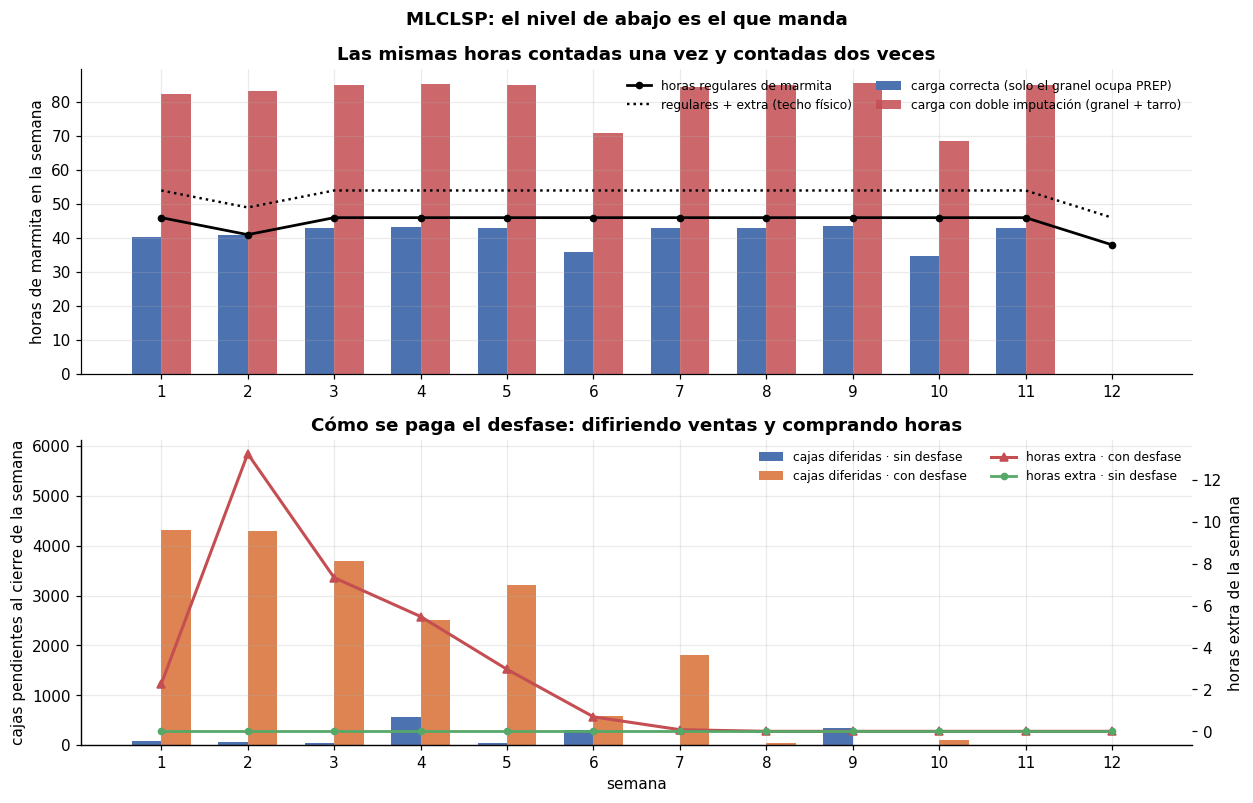

In [8]:
carga_ok = {t: sum(consumo_comp[(c, "PREP")] * v_ok["X"][c, t].X for c in COMP)
            + sum(tiempo_setup.get((i, "PREP"), 0.0) * v_ok["y"][i, t].X
                  for i in SKUS) for t in T}
carga_doble = {t: carga_ok[t] + sum(consumo[(i, "PREP")] * v_ok["x"][i, t].X
                                    for i in SKUS) for t in T}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11.5, 7.4),
                               gridspec_kw={"height_ratios": [1, 1]})

ancho = 0.34
ax1.bar([t - ancho / 2 for t in T], [carga_ok[t] for t in T], ancho,
        color="#4c72b0", label="carga correcta (solo el granel ocupa PREP)")
ax1.bar([t + ancho / 2 for t in T], [carga_doble[t] for t in T], ancho,
        color="#c44e52", alpha=0.85,
        label="carga con doble imputación (granel + tarro)")
ax1.plot(T, [capacidad[("PREP", t)] for t in T], color="black", lw=1.8,
         marker="o", ms=4, label="horas regulares de marmita")
ax1.plot(T, [capacidad[("PREP", t)] + extra_max[("PREP", t)] for t in T],
         color="black", ls=":", lw=1.6, label="regulares + extra (techo físico)")
ax1.set_ylabel("horas de marmita en la semana")
ax1.set_xticks(T)
ax1.set_title("Las mismas horas contadas una vez y contadas dos veces")
ax1.legend(fontsize=8, ncol=2)

back_ok = {t: sum(v_ok["B"][i, t].X for i in SKUS) for t in T}
back_des = {t: sum(v_des["B"][i, t].X for i in SKUS) for t in T}
ax2.bar([t - ancho / 2 for t in T], [back_ok[t] for t in T], ancho,
        color="#4c72b0", label="cajas diferidas · sin desfase")
ax2.bar([t + ancho / 2 for t in T], [back_des[t] for t in T], ancho,
        color="#dd8452", label="cajas diferidas · con desfase")
ax2.set_ylabel("cajas pendientes al cierre de la semana")
ax2.set_xlabel("semana")
ax2.set_xticks(T)
ax3 = ax2.twinx()
ax3.plot(T, [sum(v_des["o"][r, t].X for r in REC) for t in T], color="#c44e52",
         lw=2.0, marker="^", ms=5, label="horas extra · con desfase")
ax3.plot(T, [sum(v_ok["o"][r, t].X for r in REC) for t in T], color="#55a868",
         lw=1.8, marker="o", ms=4, label="horas extra · sin desfase")
ax3.set_ylabel("horas extra de la semana")
ax3.grid(False)
h2, l2 = ax2.get_legend_handles_labels()
h3, l3 = ax3.get_legend_handles_labels()
ax2.set_ylim(0, max(back_des.values()) * 1.42)
ax2.legend(h2 + h3, l2 + l3, fontsize=8, ncol=2, loc="upper right")
ax2.set_title("Cómo se paga el desfase: difiriendo ventas y comprando horas")
fig.suptitle("MLCLSP: el nivel de abajo es el que manda", fontweight="bold")
figura(fig, "mlclsp_niveles")
plt.show()

## 7. Comprobación

Además de contrastar contra las cifras de referencia, se recalculan desde la
**solución** los dos balances que el modelo impone, sin volver a preguntarle a
Gurobi. Un balance que cuadra en las restricciones y no cuadra al recalcularlo
a mano es la señal de que el modelo escrito no es el modelo que uno cree haber
escrito.

In [9]:
print("Comprobación:")
ok = []
ok.append(verificar(m_ok.ObjVal, 21_382_808.0, "MLCLSP correcto (CLP)", tol=1e-4))
ok.append(verificar(m_des.ObjVal, 37_479_417.0, "MLCLSP con desfase (CLP)", tol=1e-4))
ok.append(verificar(m_des.ObjVal / m_ok.ObjVal, 1.753,
                    "razón desfase / sin desfase", tol=5e-3))
ok.append(verificar(float(m_mal.Status == GRB.INFEASIBLE), 1.0,
                    "la doble imputación da INFEASIBLE", tol=1e-9))
ok.append(verificar(setups_pt, 30.0, "preparaciones de envasado", tol=0.02))
ok.append(verificar(setups_gr, 19.0, "cocciones de granel", tol=0.03))

# balance del componente, recalculado desde la solución
peor = 0.0
for c in COMP:
    J_prev = inv_ini_comp[c]
    for k, t in enumerate(T):
        usa = sum(bom.get((i, c), 0.0) * v_ok["x"][i, t].X for i in SKUS)
        llega = v_ok["X"][c, t].X
        peor = max(peor, abs(J_prev + llega - usa - v_ok["J"][c, t].X))
        J_prev = v_ok["J"][c, t].X
ok.append(verificar(peor, 0.0, "residuo máximo del balance de granel (kg)", tol=1e-5))

# capacidad de PREP, recalculada desde la solución
peor_cap = 0.0
for t in T:
    carga = (sum(consumo_comp[(c, "PREP")] * v_ok["X"][c, t].X for c in COMP)
             + sum(tiempo_setup.get((i, "PREP"), 0.0) * v_ok["y"][i, t].X
                   for i in SKUS))
    peor_cap = max(peor_cap, carga - capacidad[("PREP", t)] - v_ok["o"]["PREP", t].X)
ok.append(verificar(max(0.0, peor_cap), 0.0,
                    "violación máxima de capacidad de PREP (h)", tol=1e-6))

print(f"\n{sum(ok)}/{len(ok)} comprobaciones correctas")

assert m_mal.Status == GRB.INFEASIBLE, "la doble imputación debería ser infactible"
assert m_ok.Status == GRB.OPTIMAL and m_des.Status == GRB.OPTIMAL
assert m_des.ObjVal > m_ok.ObjVal, "el desfase solo puede encarecer el plan"
assert peor < 1e-5 and peor_cap < 1e-6

plan = pd.DataFrame([{"t": t,
                      "granel_cocido_kg": sum(v_ok["X"][c, t].X for c in COMP),
                      "granel_en_bodega_kg": sum(v_ok["J"][c, t].X for c in COMP),
                      "cajas_envasadas": sum(v_ok["x"][i, t].X for i in SKUS),
                      "h_PREP": carga_ok[t],
                      "h_extra": sum(v_ok["o"][r, t].X for r in REC)} for t in T])
tabla(plan, "mlclsp_plan")
tabla(puente, "mlclsp_puente_horas")
resumen({"mlclsp_correcto_clp": float(m_ok.ObjVal),
         "mlclsp_desfase_clp": float(m_des.ObjVal),
         "razon_desfase": float(m_des.ObjVal / m_ok.ObjVal),
         "doble_imputacion_estado": ESTADO.get(m_mal.Status, str(m_mal.Status)),
         "setups_producto": setups_pt, "setups_granel": setups_gr,
         "utilizacion_PREP_correcta_pct": float(100 * h_granel / h_disp_extra),
         "utilizacion_PREP_doble_pct": float(100 * (h_granel + h_imputada) / h_disp_extra)},
        "resumen_mlclsp")
print("Guardado en resultados/")

Comprobación:
  [  OK  ] MLCLSP correcto (CLP): obtenido 21,382,808.4804 | referencia 21,382,808.0000 | dif. relativa 2.25e-08
  [  OK  ] MLCLSP con desfase (CLP): obtenido 37,479,416.8304 | referencia 37,479,417.0000 | dif. relativa 4.53e-09
  [  OK  ] razón desfase / sin desfase: obtenido 1.7528 | referencia 1.7530 | dif. relativa 1.24e-04
  [  OK  ] la doble imputación da INFEASIBLE: obtenido 1.0000 | referencia 1.0000 | dif. relativa 0.00e+00
  [  OK  ] preparaciones de envasado: obtenido 30.0000 | referencia 30.0000 | dif. relativa 0.00e+00
  [  OK  ] cocciones de granel: obtenido 19.0000 | referencia 19.0000 | dif. relativa 0.00e+00
  [  OK  ] residuo máximo del balance de granel (kg): obtenido 0.0000 | referencia 0.0000 | dif. relativa 2.91e-11
  [  OK  ] violación máxima de capacidad de PREP (h): obtenido 0.0000 | referencia 0.0000 | dif. relativa 0.00e+00

8/8 comprobaciones correctas
Guardado en resultados/


> **Nota de reproducibilidad.** El README del repositorio del caso reporta
> 21 388 506 y 37 524 898 para estos dos modelos. Las cifras de este cuaderno
> (21 382 808 y 37 479 417) se obtienen con `MIPGap = 0` y son estrictamente
> óptimas, de modo que la diferencia no es de tolerancia del solver sino de
> versión del modelo. Cuando una referencia y una corrida no coinciden, lo que
> hay que fijar es **cuál de las dos se puede reproducir hoy**, y esa es la que
> queda en el cuaderno.

---

## Para llevarse

1. **Bajar un nivel obliga a QUITAR algo, no solo a agregarlo.** Las horas del
   recurso del nivel inferior las consume el componente. Si el consumo del
   producto terminado sigue ahí, la carga del cuello de botella se cuenta dos
   veces y el modelo pasa de una utilización del 72 % a una del 143 % sin que
   cambie ningún dato de la planta.
2. **`INFEASIBLE` casi nunca significa "falta capacidad".** Significa que dos
   restricciones son incompatibles, y el IIS dice cuáles. Aquí apunta a las
   marmitas, pero el problema no está en las marmitas: está en la contabilidad
   de sus horas. Subir la capacidad hubiera tapado el error y devuelto un plan
   creíble y falso.
3. **La demanda del componente no es un dato: es una decisión de arriba.** Ese
   es el único cambio estructural del MLCLSP respecto del CLSP, y es el que
   acopla los dos niveles.
4. **El supuesto de sincronización vale 16 millones.** Que el granel de la
   semana `t` se envase en `t` o en `t+1` no es un detalle de implementación:
   es el dato que hay que ir a preguntar a la planta antes de entregar un plan.

## Ejercicios

1. Reemplace el desfase de un período por un desfase de **dos** y prediga,
   antes de correr, si el costo crece más o menos que de 0 a 1 período.
   Explique el resultado mirando el inventario inicial de granel.
2. El costo de cocción del granel está fijado en 240 000 CLP y su almacenaje en
   34 CLP por kg y semana. Barra el costo de cocción entre 60 000 y 960 000 y
   grafique el número de cocciones y el inventario medio de granel. ¿A partir de
   qué valor el plan deja de cocinar semana a semana?
3. Resuelva el CLSP de un solo nivel del cuaderno 03 y el MLCLSP de este, y
   compare el **plan de envasado** (no el costo). ¿Coinciden las semanas de
   producción? Si no coinciden, ¿qué decisiones del nivel de abajo explican la
   diferencia, y qué le habría entregado a la planta el modelo de un nivel?